In [3]:
import random
import numpy as np
import pandas as pd
import itertools
from collections import Counter
from itertools import combinations
from scipy.stats import entropy
import matplotlib.pyplot as plt
import seaborn as sns


NUM_PATHOGENS = 1000                # Number Pathogens
GENERATIONS = 100
MUTATION_PATHOGEN = 0.5             # Probability self bit flips


# Biological Abstraction Functions

In [15]:
def random_bitstring(n):
    return ''.join(random.choice('01') for _ in range(n))


# Self vs non-self similarity rule
def r_contiguous_match(s1, s2, r):
    """
    Return True if s1 and s2 share at least r contiguous matching symbols
    """
    count = 0
    for i in range(len(s1)):
        if s1[i] == s2[i]:
            count += 1
            if count >= r:
                return True
        else:
            count = 0
    return False

def mutate_bitstring(s, mutation_rate):
    bits = list(s)

    for i in range(len(bits)):
        if random.random() < mutation_rate:
            bits[i] = '1' if bits[i] == '0' else '0'

    return ''.join(bits)

def shannon(bitstrings):
    counts = Counter(bitstrings)
    return entropy(list(counts.values()))

def hamming(a, b):
    return sum(x != y for x, y in zip(a, b))

def mean_hamming(bitstrings):
    if len(bitstrings) < 2:
        return 0

    distances = [
        hamming(a, b)
        for a, b in combinations(bitstrings, 2)
    ]

    return np.mean(distances)

# Detector Class

In [16]:
class Detector:
    def __init__(self, bitstring, r, MUTATION_DETECTOR):
        self.bitstring = bitstring
        self.r = r
        self.MUTATION_DETECTOR = MUTATION_DETECTOR
        self.fitness = 1.0

    def detect(self, pathogen):
        # Made deterministic: directly return if a match is found, no longer using DETECTION_SUCCESS
        return r_contiguous_match(self.bitstring, pathogen.bitstring, self.r)

# Pathogen Class

In [17]:
class Pathogen:

    def __init__(self, bitstring, MUTATION_PATHOGEN, l):
        self.bitstring = bitstring
        self.MUTATION_PATHOGEN = MUTATION_PATHOGEN
        self.l = l
        self.fitness = 0.0

    def protein_score(self):
        """
        Preserves pathogen structure: more 1s = better. 
        protein score = number of "1" / Number of bits 
        """
        return self.bitstring.count('1') / self.l

    def detection_score(self, detectors):
        """
        Less recognisable = higher score
        detection score = number of detections
        """
        if not detectors:
            return 0.0
        
        detections = sum(1 for d in detectors if d.detect(self))
        return detections > 0

    def evaluate_fitness(self, detectors):
        
        if (self.detection_score(detectors)):
            self.fitness = 0.0 
        else:
            self.fitness = self.protein_score()
            
    # Mutation
    def mutate(self):
        self.bitstring = mutate_bitstring(self.bitstring, self.MUTATION_PATHOGEN)
    
    # Crossover
    def crossover(self, other):
        point = random.randint(1, self.l - 1)
        child_bitstring = (self.bitstring[:point] + other.bitstring[point:])

        # Inherit parameters from either parent
        mutation_rate = (self.MUTATION_PATHOGEN + other.MUTATION_PATHOGEN) / 2

        return Pathogen(child_bitstring, mutation_rate, self.l)
      
    def __repr__(self):
        return (f"Pathogen(bitstring='{self.bitstring}', fitness={self.fitness:.3f})")

# Negative Selection Algorithm 

In [18]:
# Negative Selection Algorithm

def generate_detectors(NUM_DETECTORS, l, R):

    detectors = []
    SELF = "0" * l   
       
    while len(detectors) < NUM_DETECTORS:
        # Random detectors are generated with a random R and Mutation Rate
        candidate = random_bitstring(l)
        # Negative Selection: detectors recognizing "SELF" are removed
        if not r_contiguous_match(candidate, SELF, R):
            detectors.append(Detector(candidate, R, MUTATION_DETECTOR))
    return detectors


def generate_pathogens(NUM_PATHOGENS, l):
    pathogens = []
    for _ in range(NUM_PATHOGENS):

        # start pathogen near all-ones
        #s = ''.join(
            #random.choice(['1', '1', '1', '0'])
            #for _ in range(l)
        #)
        
        pathogen = random_bitstring(l)
        pathogens.append(Pathogen(pathogen, MUTATION_PATHOGEN, l))

    return pathogens


# Self Evolution (Genetic Algorithm)

In [19]:
# Self Evolution (Genetic Algorithm) Pathogen

def evolve_pathogens(pathogens, detectors):

    # evaluate fitness
    for p in pathogens:
        p.evaluate_fitness(detectors)

    # sort pathogens based on fitness 
    pathogens.sort(key=lambda x: x.fitness, reverse=True) 

    # Elitism: it keeps only 50% of the best. (Natural Selection)
    survivors = pathogens[:NUM_PATHOGENS // 2]
    children = []

    while len(children) < NUM_PATHOGENS // 2:
        
        # Select random parent2
        parent1 = random.choice(survivors)
        parent2 = random.choice(survivors)

        # Crossover between parents 
        child = parent1.crossover(parent2)
        
        # Mutation
        child.mutate()

        children.append(child)

    return survivors + children
    

# Plotting

In [20]:
# Parameters for testing
l_values = [5, 10, 20]            
r_values = [2, 3, 8]
num_detectors_grid = [500, 1000, 2000] # Representative small vs. large immune systems


REPETITIONS = 3  # Run each configuration 3 times for statistical validation


def run_simulation(l, n_detectors, r, GENERATIONS, rep):
    """
    Wraps your simulation logic. Returns the final performance metrics.
    Note: Ensure your Pathogen/Detector classes read these dynamic variables 
    instead of relying on hardcoded global variables!
    """
    
    detectors = generate_detectors(n_detectors, l, r)
    pathogens = generate_pathogens(NUM_PATHOGENS, l)
    
    # Initial detector diversity
    detector_strings = [d.bitstring for d in detectors]
    detector_shannon = shannon(detector_strings)
    detector_hamming = mean_hamming(detector_strings)
    unique_detectors = len(set(detector_strings))
    
    for generation in range(GENERATIONS):
        pathogens = evolve_pathogens(pathogens, detectors)
        
        if len(pathogens) == 0:
            mean_fitness = 0.0
            mean_protein = 0.0
            unique_pathogens = 0.0
            pathogen_shannon = 0.0
            pathogen_hamming = 0.0
        else:
            pathogen_strings = [p.bitstring for p in pathogens]

            unique_pathogens = len(set(pathogen_strings))
            pathogen_shannon = shannon(pathogen_strings)
            pathogen_hamming = mean_hamming(pathogen_strings)

            mean_fitness = np.mean([p.fitness for p in pathogens])
            mean_protein = np.mean([p.protein_score() for p in pathogens])

        # Number of detectors that detect at least one pathogen
        active_detectors = sum(
            any(d.detect(p) for p in pathogens)
            for d in detectors
        )

        # Average pathogens detected per detector
        detector_coverages = [ 
            sum(d.detect(p) for p in pathogens) / len(pathogens)
            for d in detectors
        ]

        average_detector_coverage = np.mean(detector_coverages)
        
        generation_results.append({

            "String Length (l)": l,
            "Initial Detectors (N)": n_detectors,
            "Matching Threshold (r)": r,
            "Repetition": rep,
            "Generation": generation,

            "Mean Pathogen Fitness": mean_fitness,
            "Mean Protein Score": mean_protein,

            "Unique Detectors": unique_detectors,
            "Detector Shannon": detector_shannon,
            "Detector Hamming": detector_hamming,

            "Unique Pathogens": unique_pathogens,
            "Pathogen Shannon": pathogen_shannon,
            "Pathogen Hamming": pathogen_hamming,

            "Active Detectors": active_detectors,
            "Average Detector Coverage": average_detector_coverage
        })
        

if __name__ == "__main__":
    generation_results = []
    

    # Iterate through every mathematical permutation of parameters
    for l, n_det, r in itertools.product(l_values, num_detectors_grid, r_values):
        
        # Enforce mathematical bound: threshold rule cannot exceed total string bits
        if r > l:
            continue
            
        print(f"Processing Config -> l: {l}, N: {n_det}, r: {r}")
        
        # Lists to gather statistical variance across repetitions
        rep_fitness = []
        rep_proteins = []
        
        
        for rep in range(1, REPETITIONS+1):
            run_simulation(l, n_det, r, GENERATIONS, rep)

    # Save out structured spreadsheet data directly matching report criteria
    df = pd.DataFrame(generation_results)
    df.to_csv("simulation_results.csv", index=False)
    print("\nSimulation process complete. Dataset exported to 'simulation_results.csv'.")
    
    # Showcase data head sample format
    print(df.head())

Processing Config -> l: 5, N: 500, r: 2
Processing Config -> l: 5, N: 500, r: 3
Processing Config -> l: 5, N: 1000, r: 2
Processing Config -> l: 5, N: 1000, r: 3
Processing Config -> l: 5, N: 2000, r: 2
Processing Config -> l: 5, N: 2000, r: 3
Processing Config -> l: 10, N: 500, r: 2
Processing Config -> l: 10, N: 500, r: 3
Processing Config -> l: 10, N: 500, r: 8
Processing Config -> l: 10, N: 1000, r: 2
Processing Config -> l: 10, N: 1000, r: 3
Processing Config -> l: 10, N: 1000, r: 8
Processing Config -> l: 10, N: 2000, r: 2
Processing Config -> l: 10, N: 2000, r: 3
Processing Config -> l: 10, N: 2000, r: 8
Processing Config -> l: 20, N: 500, r: 2
Processing Config -> l: 20, N: 500, r: 3
Processing Config -> l: 20, N: 500, r: 8
Processing Config -> l: 20, N: 1000, r: 2
Processing Config -> l: 20, N: 1000, r: 3
Processing Config -> l: 20, N: 1000, r: 8
Processing Config -> l: 20, N: 2000, r: 2
Processing Config -> l: 20, N: 2000, r: 3
Processing Config -> l: 20, N: 2000, r: 8

Simul

# Pathogen diversity over generations

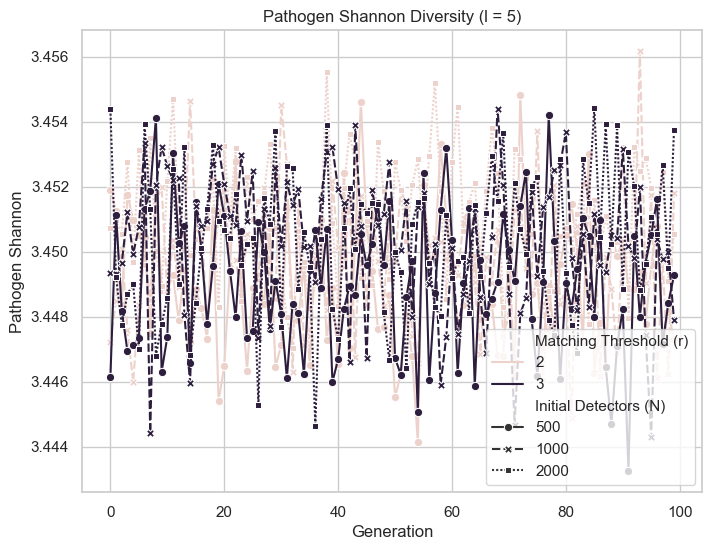

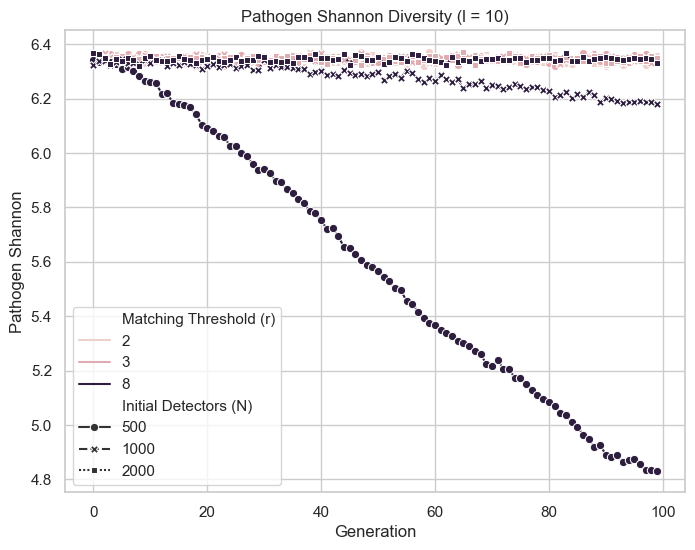

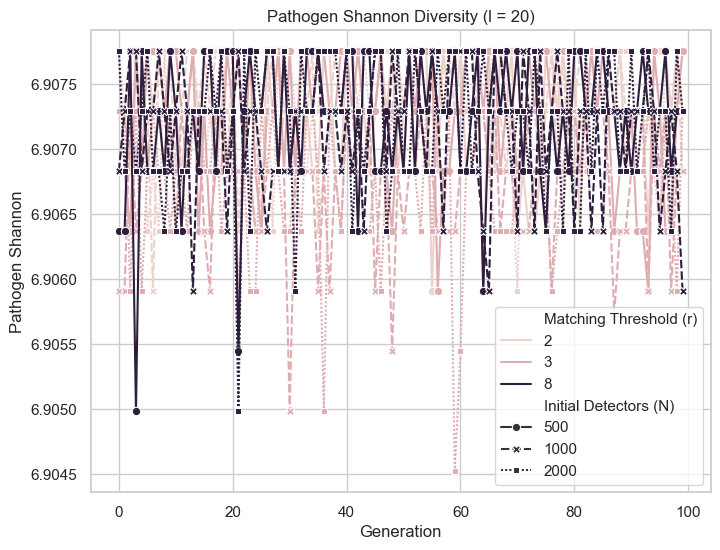

In [4]:
df = pd.read_csv("simulation_results.csv")

sns.set_theme(style="whitegrid")

plot_df = (
    df.groupby(
        ["String Length (l)",
         "Initial Detectors (N)",
         "Matching Threshold (r)",
         "Generation"],
        as_index=False
    )
    .mean(numeric_only=True)
)

for l in sorted(plot_df["String Length (l)"].unique()):

    plt.figure(figsize=(8,6))

    subset = plot_df[
        plot_df["String Length (l)"] == l
    ]

    sns.lineplot(
        data=subset,
        x="Generation",
        y="Pathogen Shannon",
        hue="Matching Threshold (r)",
        style="Initial Detectors (N)",
        markers=True
    )

    plt.title(f"Pathogen Shannon Diversity (l = {l})")

    plt.show()

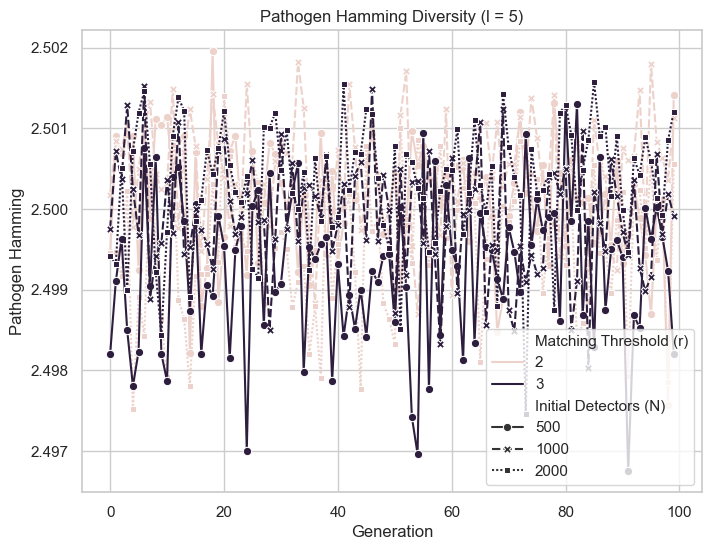

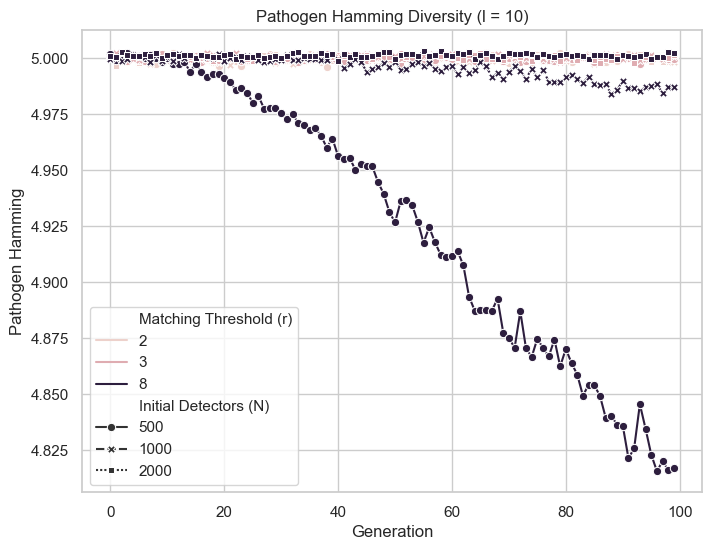

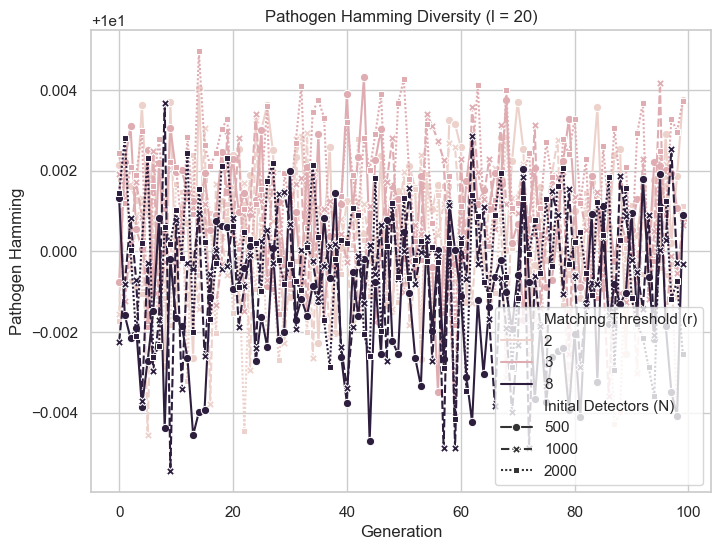

In [5]:

plot_df = (
    df.groupby(
        ["String Length (l)",
         "Initial Detectors (N)",
         "Matching Threshold (r)",
         "Generation"],
        as_index=False
    )
    .mean(numeric_only=True)
)

for l in sorted(plot_df["String Length (l)"].unique()):

    plt.figure(figsize=(8,6))

    subset = plot_df[
        plot_df["String Length (l)"] == l
    ]

    sns.lineplot(
        data=subset,
        x="Generation",
        y="Pathogen Hamming",
        hue="Matching Threshold (r)",
        style="Initial Detectors (N)",
        markers=True
    )

    plt.title(f"Pathogen Hamming Diversity (l = {l})")

    plt.show()

# Initial Detector Diversity

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:#4c72b0'` for the same effect.

  func(*plot_args, **plot_kwargs)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:#4c72b0'` for the same effect.

  func(*plot_args, **plot_kwargs)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:#4c72b0'` for the same effect.

  func(*plot_args, **plot_kwargs)


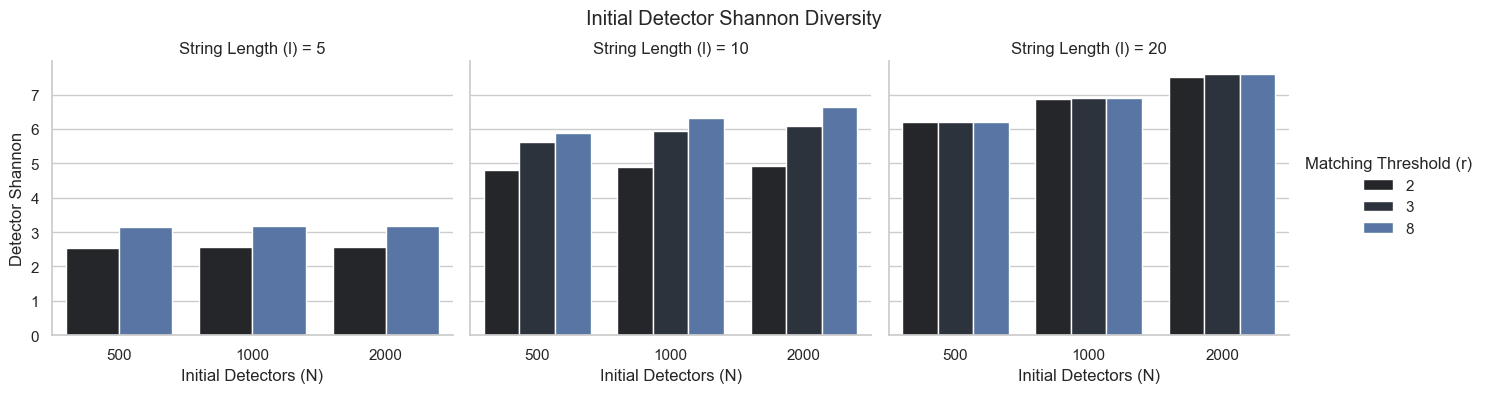

In [6]:
g = sns.FacetGrid(
    df,
    col="String Length (l)",
    height=4,
    aspect=1.1
)

g.map_dataframe(
    sns.barplot,
    x="Initial Detectors (N)",
    y="Detector Shannon",
    hue="Matching Threshold (r)"
)

g.add_legend(title="Matching Threshold (r)")

plt.subplots_adjust(top=0.85)
g.fig.suptitle("Initial Detector Shannon Diversity")

plt.show()

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:#4c72b0'` for the same effect.

  func(*plot_args, **plot_kwargs)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:#4c72b0'` for the same effect.

  func(*plot_args, **plot_kwargs)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:#4c72b0'` for the same effect.

  func(*plot_args, **plot_kwargs)


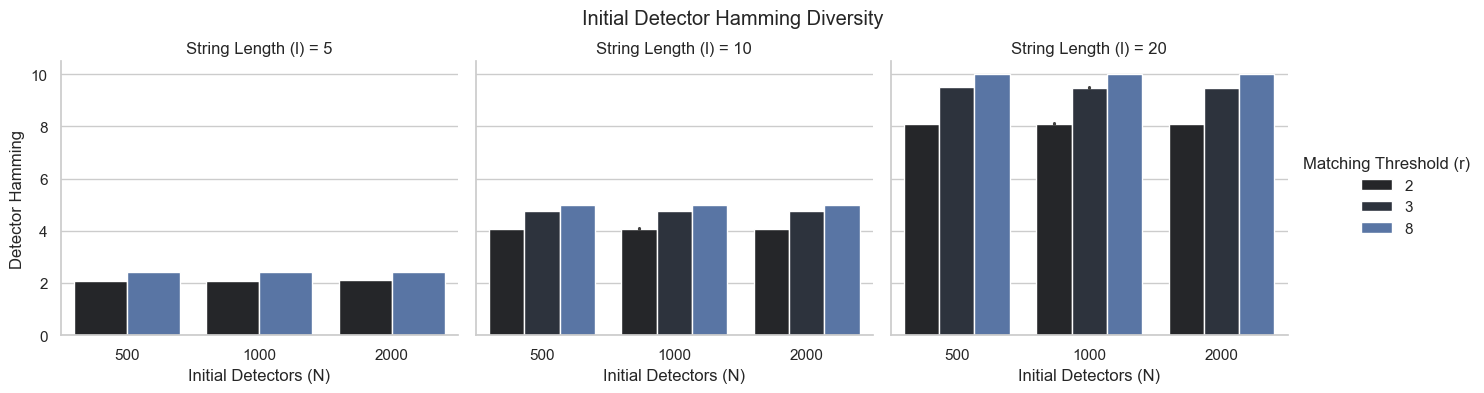

In [7]:
g = sns.FacetGrid(
    df,
    col="String Length (l)",
    height=4,
    aspect=1.1
)

g.map_dataframe(
    sns.barplot,
    x="Initial Detectors (N)",
    y="Detector Hamming",
    hue="Matching Threshold (r)"
)

g.add_legend(title="Matching Threshold (r)")

plt.subplots_adjust(top=0.85)
g.fig.suptitle("Initial Detector Hamming Diversity")

plt.show()

# Detector coverage over generations

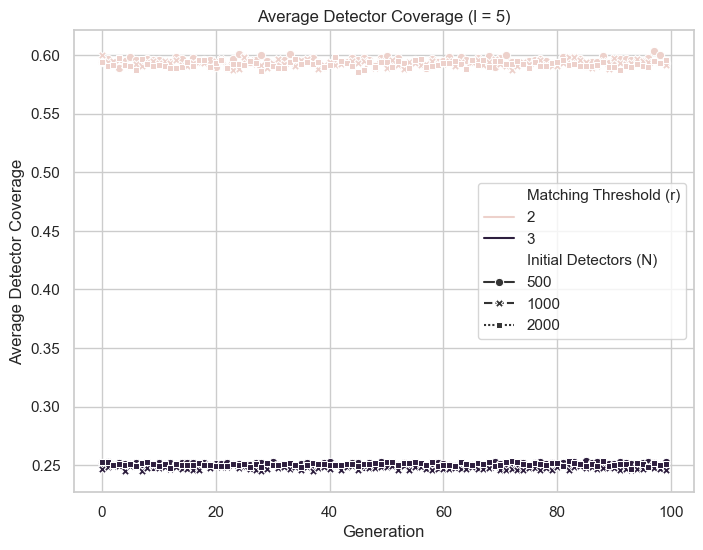

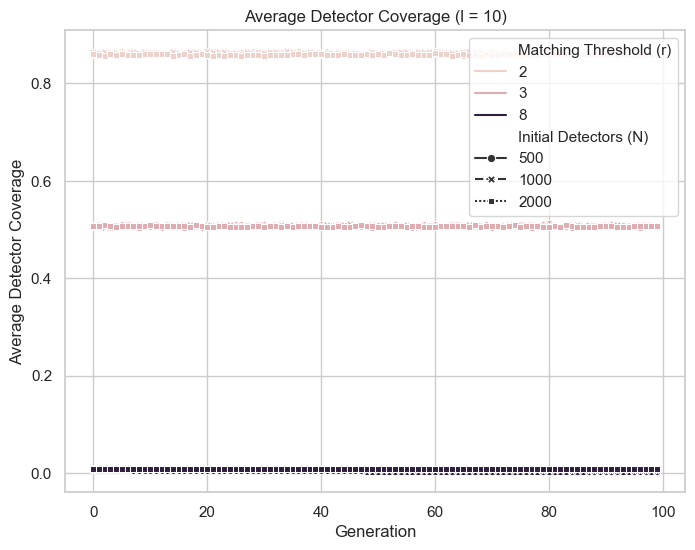

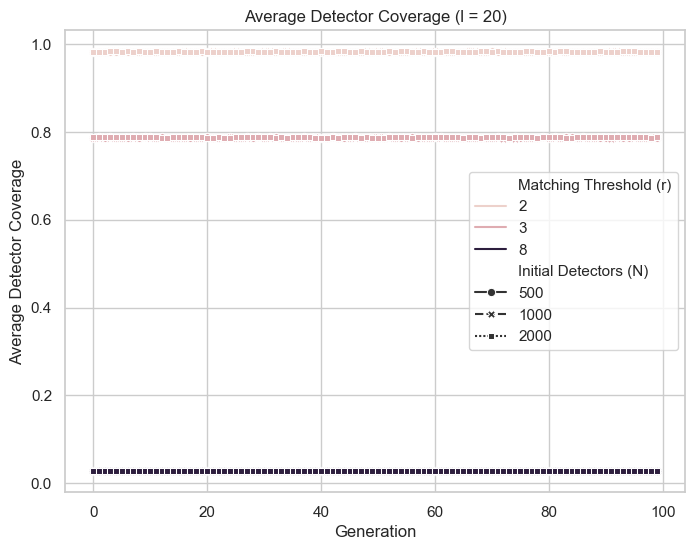

In [8]:
plot_df = (
    df.groupby(
        ["String Length (l)",
         "Initial Detectors (N)",
         "Matching Threshold (r)",
         "Generation"],
        as_index=False
    )
    .mean(numeric_only=True)
)

for l in sorted(plot_df["String Length (l)"].unique()):

    plt.figure(figsize=(8,6))

    subset = plot_df[
        plot_df["String Length (l)"] == l
    ]

    sns.lineplot(
        data=subset,
        x="Generation",
        y="Average Detector Coverage",
        hue="Matching Threshold (r)",
        style="Initial Detectors (N)",
        markers=True
    )

    plt.title(f"Average Detector Coverage (l = {l})")

    plt.show()

In [9]:
# Average repetitions
plot_df = (
    df.groupby(
        [
            "String Length (l)",
            "Initial Detectors (N)",
            "Matching Threshold (r)",
            "Generation"
        ],
        as_index=False
    )
    .mean(numeric_only=True)
)

sns.set_theme(style="whitegrid")

plt.rcParams.update({
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 12
})



# Mean Pathogen Fitness

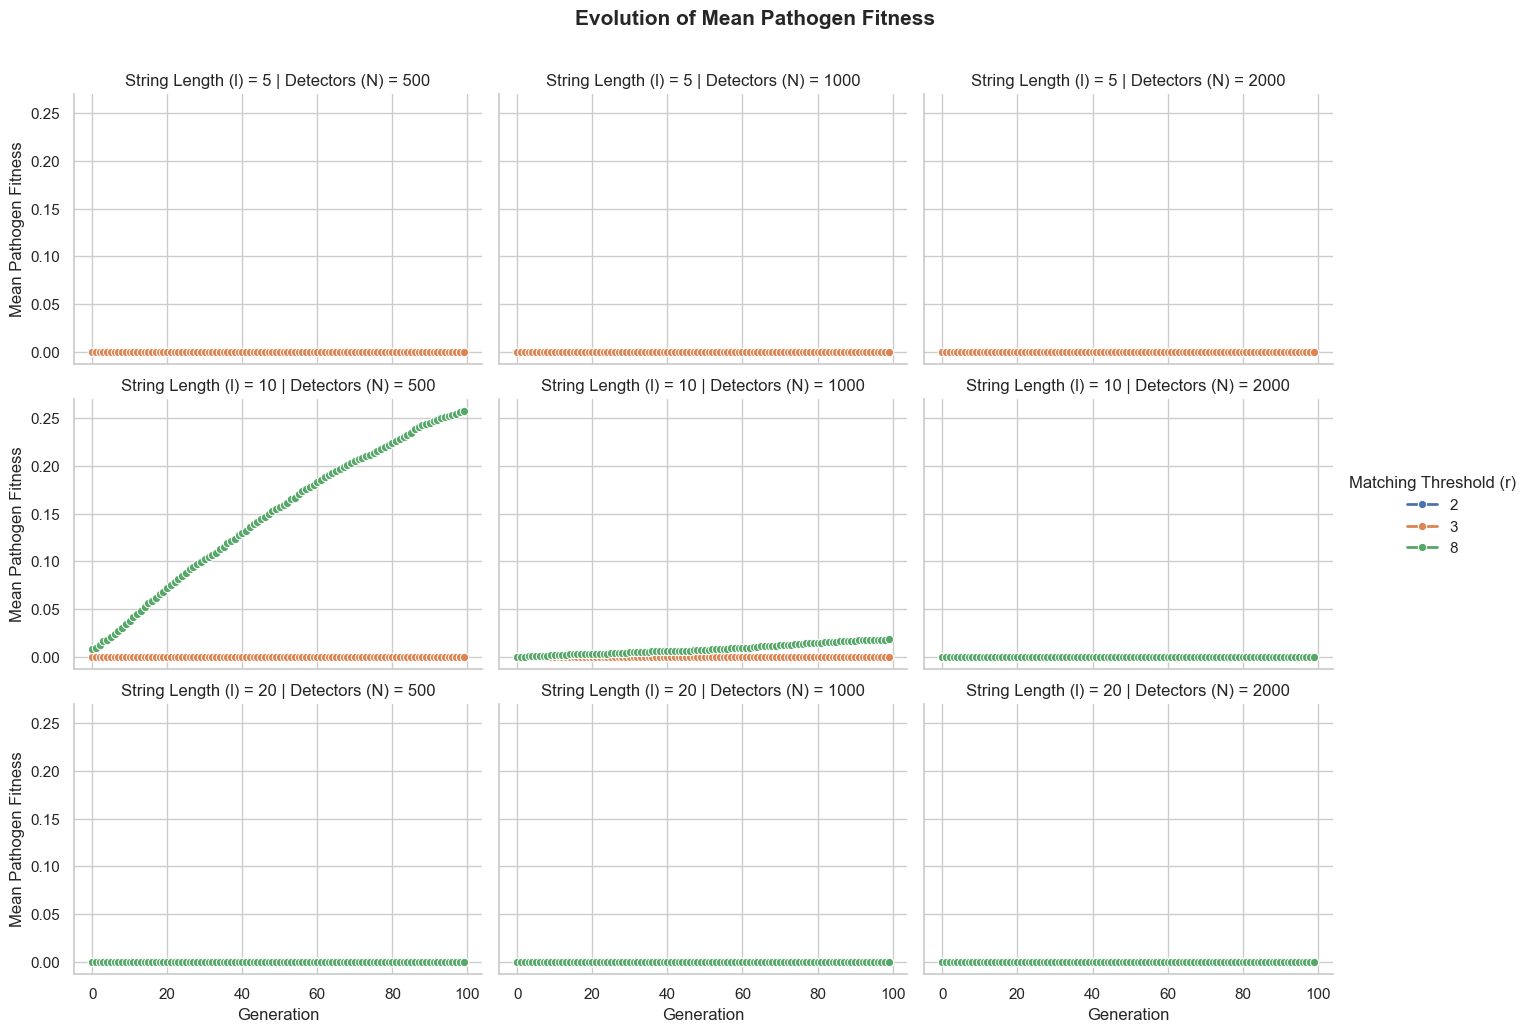

In [10]:
g = sns.FacetGrid(
    plot_df,
    row="String Length (l)",
    col="Initial Detectors (N)",
    hue="Matching Threshold (r)",
    height=3.5,
    aspect=1.3,
    sharey=True
)

g.map_dataframe(
    sns.lineplot,
    x="Generation",
    y="Mean Pathogen Fitness",
    linewidth=2,
    marker="o"
)

g.add_legend(title="Matching Threshold (r)")

g.set_axis_labels(
    "Generation",
    "Mean Pathogen Fitness"
)

g.set_titles(
    row_template="String Length (l) = {row_name}",
    col_template="Detectors (N) = {col_name}"
)

plt.subplots_adjust(top=0.90)

g.fig.suptitle(
    "Evolution of Mean Pathogen Fitness",
    fontsize=15,
    weight="bold"
)

plt.show()

# Mean Protein Score

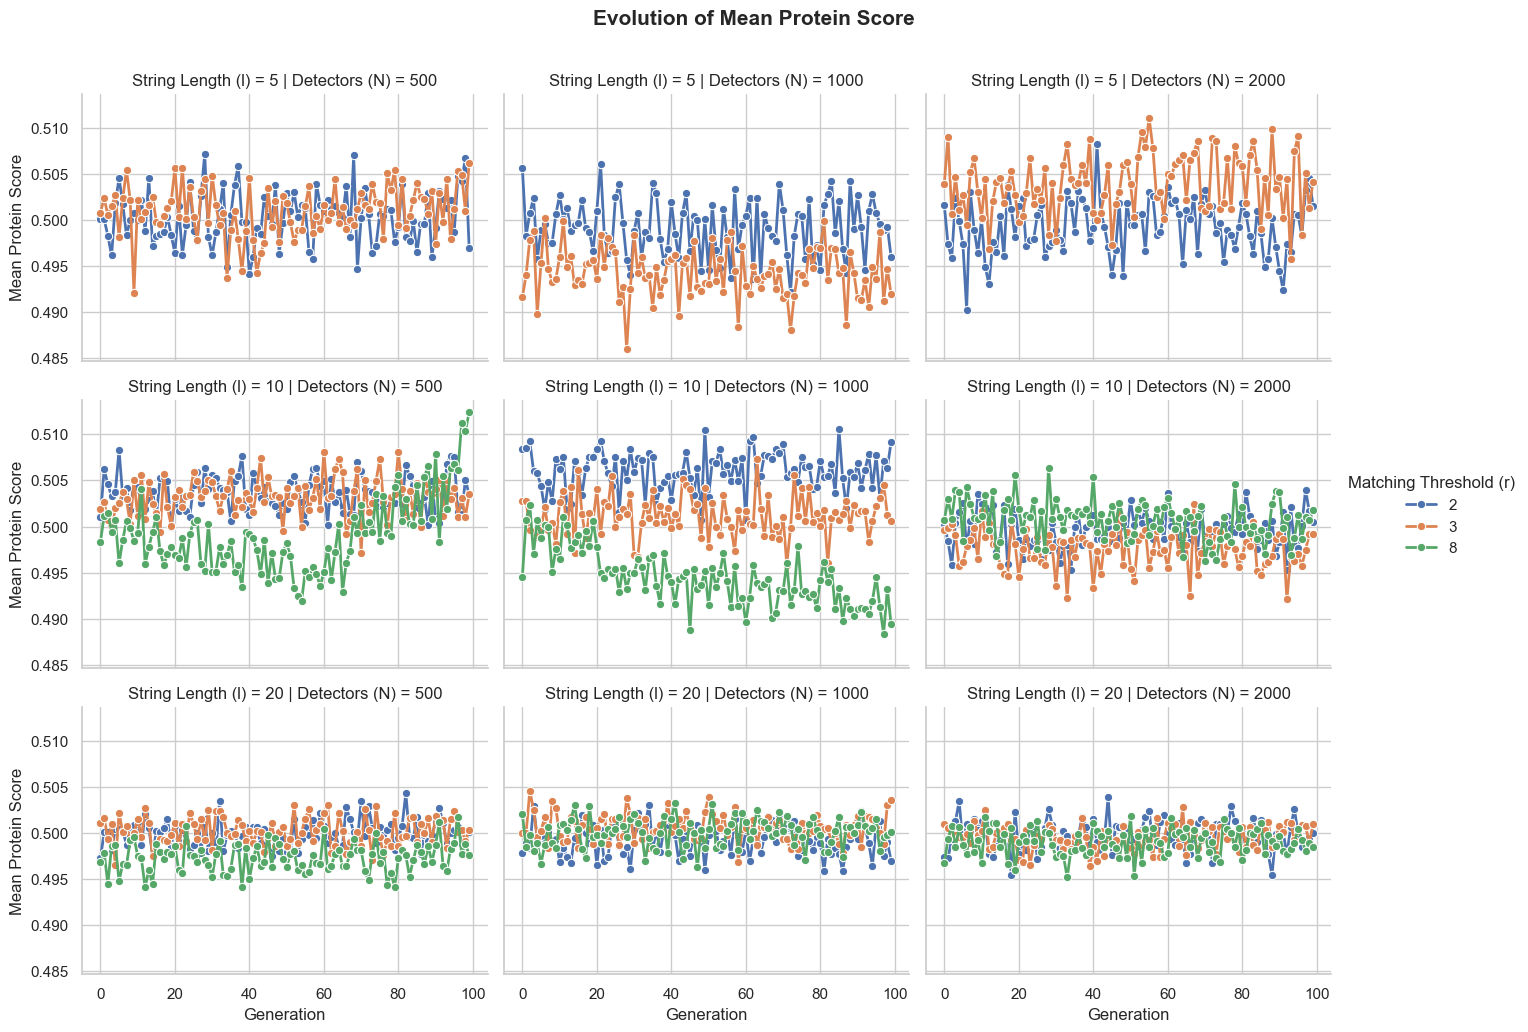

In [11]:
g = sns.FacetGrid(
    plot_df,
    row="String Length (l)",
    col="Initial Detectors (N)",
    hue="Matching Threshold (r)",
    height=3.5,
    aspect=1.3,
    sharey=True
)

g.map_dataframe(
    sns.lineplot,
    x="Generation",
    y="Mean Protein Score",
    linewidth=2,
    marker="o"
)

g.add_legend(title="Matching Threshold (r)")

g.set_axis_labels(
    "Generation",
    "Mean Protein Score"
)

g.set_titles(
    row_template="String Length (l) = {row_name}",
    col_template="Detectors (N) = {col_name}"
)

plt.subplots_adjust(top=0.90)

g.fig.suptitle(
    "Evolution of Mean Protein Score",
    fontsize=15,
    weight="bold"
)

plt.show()